In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("credit_risk_dataset.csv")

print("Dataset Loaded")

Dataset Loaded


In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

Rows and Columns:
(32581, 12)

Column Names:
Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')


In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
df.fillna(
    df.median(numeric_only=True),
    inplace=True
)

print("Missing values handled")

Missing values handled


In [8]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [9]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

print("Encoding Complete")

Encoding Complete


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  int64  
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  int64  
 5   loan_grade                  32581 non-null  int64  
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  int64  
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 3.0 MB


## Feature Engineering

Two new features were created:

1. income_per_age
   - Income divided by age.
   - Helps estimate earning capacity relative to age.

2. loan_percent_income
   - Loan amount divided by income.
   - Measures the financial burden of the requested loan.

In [11]:
df["income_per_age"] = (
    df["person_income"]
    /
    df["person_age"]
)

df["loan_percent_income"] = (
    df["loan_amnt"]
    /
    df["person_income"]
)

print("New Features Added")

New Features Added


In [12]:
df[
    [
        "income_per_age",
        "loan_percent_income"
    ]
].head()

,income_per_age,loan_percent_income
0,2681.818182,0.593220
1,457.142857,0.104167
2,384.000000,0.572917
3,2847.826087,0.534351
4,2266.666667,0.643382


In [13]:
X = df.drop(
    "loan_status",
    axis=1
)

y = df["loan_status"]

print(X.shape)
print(y.shape)

(32581, 12)
(32581,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (26064, 12)
Testing Data: (6517, 12)


In [16]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=2000)

lr_model.fit(X_train, y_train)

print("Logistic Regression Trained Successfully")

Logistic Regression Trained Successfully


c:\Users\VIVEKVIPPARLA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
lr_predictions = lr_model.predict(X_test)

print(lr_predictions[:10])

[0 0 0 0 1 0 0 0 0 0]


In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.8299831210679761


In [19]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(
    y_test,
    lr_predictions
)

recall = recall_score(
    y_test,
    lr_predictions
)

f1 = f1_score(
    y_test,
    lr_predictions
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.7042424242424242
Recall: 0.40207612456747405
F1 Score: 0.5118942731277533


In [20]:
from sklearn.metrics import roc_auc_score

lr_probabilities = lr_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    lr_probabilities
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8303923842686081


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    lr_predictions
)

print(cm)

[[4828  244]
 [ 864  581]]


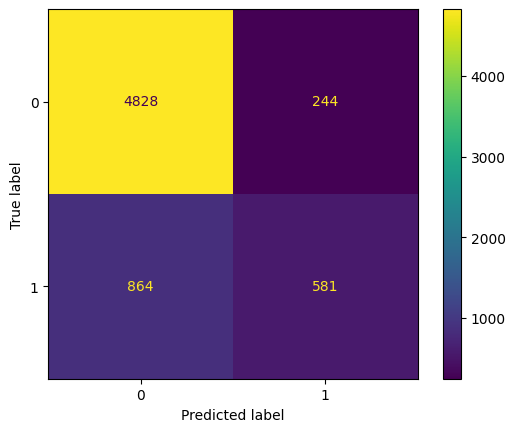

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_predictions
)

plt.show()

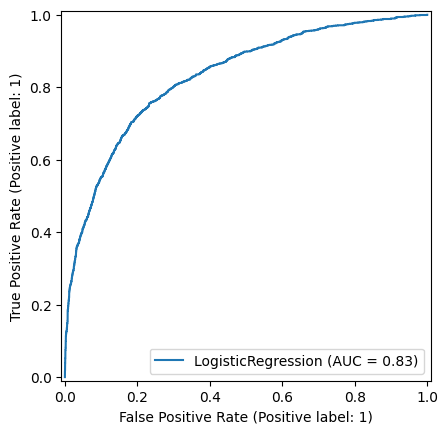

In [23]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    lr_model,
    X_test,
    y_test
)

plt.show()

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

print("Decision Tree Trained")

Decision Tree Trained


In [25]:
dt_predictions = dt_model.predict(
    X_test
)

from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8870646002762007


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest Trained")

Random Forest Trained


In [27]:
rf_predictions = rf_model.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9280343716433942


In [28]:
comparison = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy
0,Logistic Regression,0.829983
1,Decision Tree,0.887065
2,Random Forest,0.928034


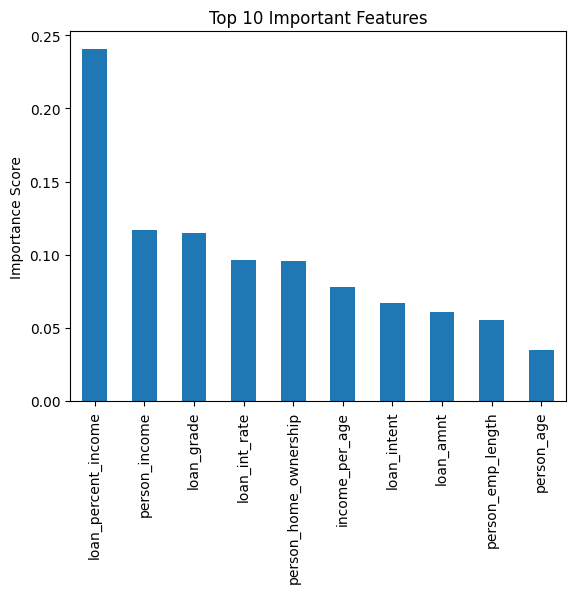

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")
plt.show()

In [30]:
import joblib

joblib.dump(
    rf_model,
    "credit_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [31]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_precision = precision_score(
    y_test,
    rf_predictions
)

rf_recall = recall_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions
)

rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
print("ROC-AUC:", rf_auc)

Precision: 0.9577861163227017
Recall: 0.7065743944636678
F1 Score: 0.8132218239745121
ROC-AUC: 0.937099128944582


# Conclusion

Three machine learning models were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Random Forest achieved the highest accuracy of 92.80%.

Evaluation metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC were used to assess model performance.

The final trained Random Forest model was saved for future credit risk prediction.